# "Alphabet-level activities" compute model

A Monte Carlo estimate of how much compute is implied by Alphabet's
**"Alphabet-level activities"** expense line, expressed in H100-equivalents
(H100e).

**Background.** Alphabet reports an operating-expense line it describes as
"primarily reflecting expenses related to our shared AI research and
development." In substance this is where most of DeepMind's R&D cost lands,
because Gemini models are a shared input to every Google segment and can't be
cleanly allocated to one. The bucket was **$16.76B in 2025** ($10.5B in 2024,
$9.19B in 2023) and **$5.39B in Q1 2026** (~$21.6B annualized).

But the line item mixes several things. Alphabet says it contains:

1. shared AI R&D — **employee compensation** *and* **technical infrastructure
   usage costs** (i.e. compute);
2. corporate initiatives such as **philanthropy**;
3. corporate shared costs — certain **finance, HR, and legal** costs,
   including **fines and settlements**.

So the dollar figure is only a *rough upper bound* on DeepMind's R&D compute
spend. Two things stand between the headline number and an H100e count, and
they are the two uncertainties this model samples:

- **What share of the bucket is compute** (vs. salaries, philanthropy, legal)?
- **How expensive is an internal H100e-hour on Google's books?** DeepMind runs
  mostly on Google-owned TPUs, so Google is selling compute to itself. It
  almost certainly books this at *cost* (depreciation + amortization + operating
  expenses), **not** at a market GPU-hour rate with a profit margin — and TPUs
  are cheaper per FLOP than Nvidia. We anchor the cost of *owning* Nvidia
  directly to SemiAnalysis's published owning-TCO estimates
  ([InferenceX](https://inferencex.semianalysis.com/inference)), then apply
  the TPU cost advantage. That makes these dollars buy *more* H100e-hours than
  the same dollars would at OpenAI or Anthropic, who rent at market rates.

**Method.** For a given period,

> `avg H100e used = (spend × compute_share) ÷ internal_$_per_H100e_hour ÷ hours_in_period`

The result is the **average number of H100e running continuously** over the
period to consume that much compute budget. It covers R&D/training only —
product inference is booked in the business segments, not here.

**All sampled inputs are lognormal.** Each low/high pair is read as the **90%
credible interval** (5th–95th percentile).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq
from squigglepy.numbers import B

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions/prices and shown as decimals;
    larger values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p

## Canonical parameters

The sampled priors are loaded from `lab_model_params.csv` (lab
`alphabet_activities`) — the shared source of truth for the lab compute
models. Edit the sheet (leaving a note in its description column) to change
a prior. The two share parameters are clipped at 1 so no sample implies more
than 100% of a whole.

In [2]:
from lab_compute_utils import load_lab_params, lab_params_table

PARAMS = load_lab_params()["alphabet_activities"]
lab_params_table("alphabet_activities")

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,compute_share,to,0.3,0.70,NaN,1.0,share,Share of the Alphabet-level activities expense...,7/2/26
1,nvidia_tco,to,0.9,1.40,NaN,NaN,USD/H100e-hr,"Nvidia owning-TCO per H100e-hr, anchored to Se...",7/7/26
2,tpu_vs_nvidia_tco,to,0.5,0.78,NaN,NaN,ratio,TPU vs Nvidia TCO per marketed 8-bit PFLOP (Se...,7/2/26
3,tpu_share,to,0.7,0.90,NaN,1.0,share,TPU share of the DeepMind fleet cost blend; cl...,7/2/26


## Known inputs: the reported spend

These come straight from Alphabet's filings, so we treat them as fixed rather
than sampling them. We run the model for two periods:

- **Q1 2026** — the most recent data point ($5.39B per the 10-Q), giving the
  freshest snapshot.
- **Full-year 2025** ($16.76B) — for comparison / an annual average.

The number of hours in the period is what turns a pile of compute-dollars into
an *average concurrent* chip count.

In [3]:
spend_q1_2026 = 5.391 * B    # Alphabet-level activities, Q1 2026 (10-Q: $5,391M)
spend_fy_2025 = 16.76 * B    # Alphabet-level activities, full-year 2025

# Hours in each period. Q1 = Jan+Feb+Mar = 90 days; a full year = 8760 hours.
hours_q1_2026 = 90 * 24      # 2160
hours_fy_2025 = 8760

print(f"Q1 2026 spend: ${spend_q1_2026/1e9:.1f}B over {hours_q1_2026} hours")
print(f"FY 2025 spend: ${spend_fy_2025/1e9:.2f}B over {hours_fy_2025} hours")

Q1 2026 spend: $5.4B over 2160 hours
FY 2025 spend: $16.76B over 8760 hours


## Uncertainty 1: what share of the bucket is compute?

The bucket is predominantly AI R&D (Alphabet added a one-line summary in 2025
emphasizing this), and within AI R&D the two ingredients are employee
compensation and "technical infrastructure usage costs" (compute). The rest is
corporate overhead — philanthropy, finance/HR/legal, and lumpy fines and
settlements.

Rough sizing of the *non-compute* pieces against a ~$17–21B annualized bucket:

- **DeepMind compensation:** on the order of a few thousand researchers/engineers
  at fully-loaded costs of several hundred $k each ⇒ very roughly $3–4B/yr.
- **Overhead** (philanthropy + shared finance/HR/legal + settlements): another
  few $B/yr, and *lumpy* — a large settlement in one period can swing this.

That leaves compute as somewhere around **a third to two-thirds** of the total,
with wide uncertainty. We use a 90% CI of **0.30–0.70** (lognormal, median ~0.46).
This deliberately doesn't try to strip out the further wrinkles that some
DeepMind R&D may be booked in a product segment instead, or that some compute
here isn't strictly frontier R&D — those are discussed as caveats below.

In [4]:
compute_share = PARAMS["compute_share"]
compute_share_samples = compute_share @ N_SAMPLES
summary("Compute share of Alphabet-level activities", compute_share_samples);

Compute share of Alphabet-level activities
  90% CI : 0.297 – 0.695
  median : 0.458
  mean   : 0.471


## Uncertainty 2: the internal cost of an H100e-hour

This is the crux, and the reason Alphabet-level dollars are *apples-to-oranges*
with OpenAI's or Anthropic's cloud bills. Google runs DeepMind mostly on its own
TPUs and bills the cost internally — depreciation + amortization + operating
expenses — with **no cloud profit margin**. Google's self-built TPUs are also
cheaper per FLOP than renting Nvidia. We build the cost up in three steps.

**Step 1 — Nvidia owning-TCO anchor (SemiAnalysis InferenceX).** SemiAnalysis
publishes the direct total cost of ownership of an Nvidia GPU-hour for an
owner-operator, on [InferenceX](https://inferencex.semianalysis.com/inference)
("Owning – Hyperscaler" basis, August 2025 pricing surveys & AI Cloud TCO
model). This is exactly the quantity we want — a hyperscaler's own all-in cost,
with no cloud margin to strip out. Converting each chip's per-GPU-hour TCO to
$/H100e-hr (GB200 and GB300 each ≈ 2.5 H100e):

| Chip | TCO $/GPU-hr | H100e per GPU | TCO $/H100e-hr |
|------|-------------:|--------------:|---------------:|
| H100 | 1.30 | 1.0 | 1.30 |
| H200 | 1.41 | 1.0 | 1.41 |
| GB200 | 2.21 | 2.5 | 0.88 |
| GB300 | 2.34 | 2.5 | 0.94 |

So Hopper costs about **$1.30–1.41 per H100e-hr** to own, and Blackwell's
better performance-per-TCO brings that down to **$0.88–0.94**. Google's Nvidia
fleet over FY 2025 – Q1 2026 is a Hopper/Blackwell mix shifting toward
Blackwell, so we take a 90% CI of **$0.90–1.40/H100e-hr**: a nearly-all-Blackwell
fleet at the low end, nearly-all-Hopper at the high end, which also leaves room
for SemiAnalysis model error either way.

**Step 2 — TPU vs Nvidia cost advantage (from SemiAnalysis).** On a *TCO per
marketed 8-bit PFLOP* basis — the right normalization for H100e — SemiAnalysis's
[TPU v7 analysis](https://newsletter.semianalysis.com/p/tpuv7-google-takes-a-swing-at-the)
puts TPU v7 (internal) at **$0.28** vs Nvidia GB200 at **$0.46** and GB300 at
**$0.55**. So a TPU delivers the same FP8 throughput at roughly **0.51–0.76×**
Nvidia's cost (central ~0.61). Generalizing "TPU v7 : GB200" to "TPU : Nvidia
fleet-wide," we take **0.50–0.78**. TPU internal cost = Nvidia owning TCO ×
this ratio.

**Step 3 — blend by fleet mix.** DeepMind's fleet is TPU-heavy but part is
Nvidia (Google overall is ~¾ TPU by H100e; DeepMind likely at least that
TPU-weighted). We take the **TPU share at 0.70–0.90** and blend the two costs.

The result lands just under **$0.8/H100e-hr**. As a consistency check, the two
SemiAnalysis sources agree well where they overlap: the TPU-v7 newsletter's
GB200 TCO converts to $0.46 × 1.979 ≈ **$0.91/H100e-hr**, vs **$0.88** from the
InferenceX numbers above (GB300 is less tight: $1.09 vs $0.94).

In [5]:
# Step 1: Nvidia owning TCO per H100e-hour, anchored to SemiAnalysis InferenceX
# ("Owning - Hyperscaler" basis, August 2025). Show the anchor points first.
inferencex_owning_tco = {
    # chip: (TCO $ per GPU-hr, H100e per GPU)
    "H100": (1.30, 1.0),
    "H200": (1.41, 1.0),
    "GB200": (2.21, 2.5),
    "GB300": (2.34, 2.5),
}
print("SemiAnalysis InferenceX owning TCO, converted to $/H100e-hr:")
for chip, (tco_per_gpu, h100e_per_gpu) in inferencex_owning_tco.items():
    print(f"  {chip:6s} ${tco_per_gpu:.2f}/GPU-hr / {h100e_per_gpu:.1f} H100e"
          f" = ${tco_per_gpu / h100e_per_gpu:.2f}/H100e-hr")
print()

nvidia_tco = PARAMS["nvidia_tco"] @ N_SAMPLES

# Step 2: TPUs are cheaper per 8-bit FLOP (SemiAnalysis TPU-v7 : Nvidia TCO ratio).
tpu_vs_nvidia_tco = PARAMS["tpu_vs_nvidia_tco"] @ N_SAMPLES
tpu_internal_cost = nvidia_tco * tpu_vs_nvidia_tco

# Step 3: blend by DeepMind's TPU-heavy-but-not-all-TPU fleet mix.
tpu_share = PARAMS["tpu_share"] @ N_SAMPLES
cost_samples = tpu_share * tpu_internal_cost + (1 - tpu_share) * nvidia_tco

summary("Nvidia owning TCO $/H100e-hr", nvidia_tco)
summary("TPU internal cost $/H100e-hr", tpu_internal_cost)
summary("Blended internal $/H100e-hour", cost_samples)

# Consistency check: the TPU-v7 newsletter quotes TCO per marketed 8-bit PFLOP;
# converting at 1 H100e = 1.979 FP8 PFLOP/s should roughly match InferenceX.
print("\nSemiAnalysis TPU-v7 newsletter TCO, converted ($/H100e-hr):")
for chip, tco_per_pflop in [("GB200", 0.46), ("GB300", 0.55),
                            ("TPU v7 internal", 0.28), ("TPU v7 external", 0.35)]:
    print(f"  {chip:18s} {tco_per_pflop * 1.979:.2f}")

SemiAnalysis InferenceX owning TCO, converted to $/H100e-hr:
  H100   $1.30/GPU-hr / 1.0 H100e = $1.30/H100e-hr
  H200   $1.41/GPU-hr / 1.0 H100e = $1.41/H100e-hr
  GB200  $2.21/GPU-hr / 2.5 H100e = $0.88/H100e-hr
  GB300  $2.34/GPU-hr / 2.5 H100e = $0.94/H100e-hr

Nvidia owning TCO $/H100e-hr
  90% CI : 0.898 – 1.404
  median : 1.119
  mean   : 1.133
TPU internal cost $/H100e-hr
  90% CI : 0.510 – 0.958
  median : 0.699
  mean   : 0.713
Blended internal $/H100e-hour
  90% CI : 0.591 – 1.041
  median : 0.786
  mean   : 0.798

SemiAnalysis TPU-v7 newsletter TCO, converted ($/H100e-hr):
  GB200              0.91
  GB300              1.09
  TPU v7 internal    0.55
  TPU v7 external    0.69


## Putting it together

For each period: turn spend into compute-dollars, divide by the internal
hourly cost to get H100e-hours, then divide by hours in the period to get the
average number of H100e running continuously.

In [6]:
def h100e_from_spend(spend, hours):
    """Average concurrent H100e implied by a spend figure over `hours` hours."""
    compute_dollars = spend * compute_share_samples
    h100e_hours = compute_dollars / cost_samples
    return h100e_hours / hours


h100e_q1_2026 = h100e_from_spend(spend_q1_2026, hours_q1_2026)
h100e_fy_2025 = h100e_from_spend(spend_fy_2025, hours_fy_2025)

p_q1 = summary("H100e for Alphabet-level activities — Q1 2026", h100e_q1_2026)
p_fy = summary("H100e for Alphabet-level activities — FY 2025 avg", h100e_fy_2025);

H100e for Alphabet-level activities — Q1 2026
  90% CI : 863k – 2.41M
  median : 1.46M
  mean   : 1.52M
H100e for Alphabet-level activities — FY 2025 avg
  90% CI : 661k – 1.85M
  median : 1.12M
  mean   : 1.17M


## Headline distribution — Q1 2026

The freshest snapshot. Note the long right tail: the estimate is dominated by
the two multiplicative uncertainties, and a low internal cost combined with a
high compute share pushes it well past 2M H100e.

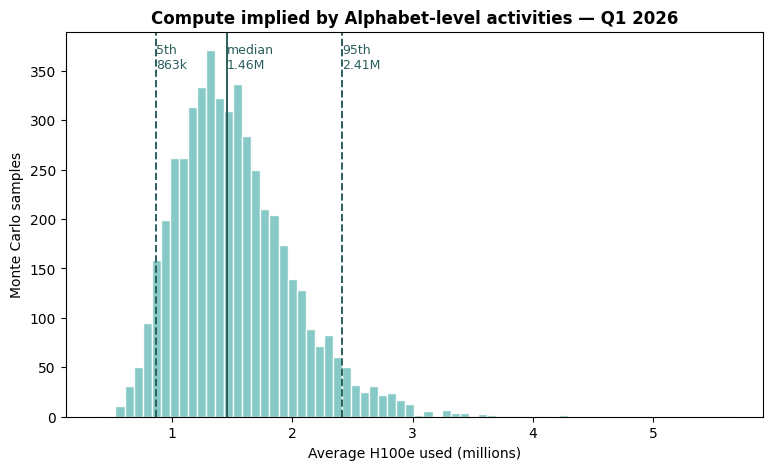

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(h100e_q1_2026 / 1e6, bins=70, color="#7AC4C0", alpha=0.9,
        edgecolor="white")
for q, style, lbl in [(5, "--", "5th"), (50, "-", "median"), (95, "--", "95th")]:
    v = p_q1[q] / 1e6
    ax.axvline(v, color="#2B5F5C", ls=style, lw=1.4)
    ax.text(v, ax.get_ylim()[1] * 0.97, f"{lbl}\n{fmt(p_q1[q])}", rotation=0,
            va="top", ha="left", fontsize=9, color="#2B5F5C")
ax.set_xlabel("Average H100e used (millions)")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("Compute implied by Alphabet-level activities — Q1 2026",
             weight="bold")
plt.show()

## The two uncertainties, visualized

Because the estimate is essentially `constant × compute_share ÷ cost_per_hour`,
the whole picture is a 2-D surface over the two sampled inputs. The heatmap
shows the median H100e at each combination; the dashed lines mark each input's
90% CI. The estimate is far more sensitive to the internal-cost assumption than
to the compute share.

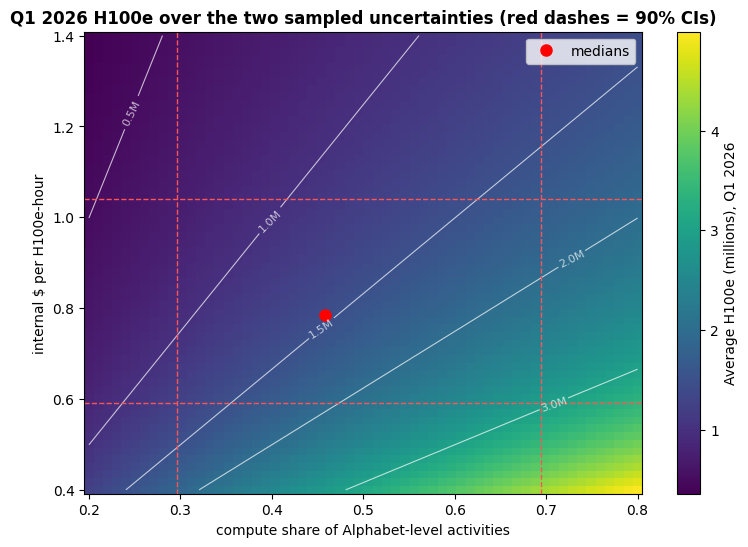

In [8]:
share_grid = np.linspace(0.20, 0.80, 60)
cost_grid = np.linspace(0.40, 1.40, 60)
S, C = np.meshgrid(share_grid, cost_grid)
grid_h100e = (spend_q1_2026 * S / C / hours_q1_2026) / 1e6  # millions

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(share_grid, cost_grid, grid_h100e, cmap="viridis",
                   shading="auto")
cs = ax.contour(share_grid, cost_grid, grid_h100e, levels=[0.5, 1, 1.5, 2, 3],
                colors="white", linewidths=0.8, alpha=0.7)
ax.clabel(cs, fmt=lambda v: f"{v:.1f}M", fontsize=8)
# 90% CI boxes for each input
for v in (compute_share_samples,):
    lo, hi = np.percentile(v, [5, 95])
    ax.axvline(lo, color="#ff5555", ls="--", lw=1); ax.axvline(hi, color="#ff5555", ls="--", lw=1)
for v in (cost_samples,):
    lo, hi = np.percentile(v, [5, 95])
    ax.axhline(lo, color="#ff5555", ls="--", lw=1); ax.axhline(hi, color="#ff5555", ls="--", lw=1)
ax.plot(np.median(compute_share_samples), np.median(cost_samples), "o",
        color="red", ms=8, label="medians")
fig.colorbar(im, ax=ax, label="Average H100e (millions), Q1 2026")
ax.set_xlabel("compute share of Alphabet-level activities")
ax.set_ylabel("internal $ per H100e-hour")
ax.set_title("Q1 2026 H100e over the two sampled uncertainties (red dashes = 90% CIs)",
             weight="bold")
ax.legend(loc="upper right")
plt.show()

## Comparison with the previous margin-stripping approach

The previous version of this model reached Nvidia's internal cost indirectly:
start from the market price to *rent* an H100e ($1.50–2.00/hr, a price that
includes the cloud provider's profit) and strip an assumed cloud gross margin
(20–45%). That required a judgment call about margins to back out a quantity
SemiAnalysis now publishes directly. The old chain is kept below as literal
in-notebook distributions (its rows were removed from the params sheet); the
TPU-ratio and fleet-mix samples are reused so the only difference between old
and new is the Nvidia cost anchor.

In [9]:
# Old approach: market rental price with an assumed cloud gross margin stripped out.
old_market_price = sq.to(1.5, 2.0) @ N_SAMPLES
old_cloud_margin = sq.to(0.2, 0.45) @ N_SAMPLES
old_nvidia_cost = old_market_price * (1 - old_cloud_margin)

# Same downstream steps as the new model, swapping only the Nvidia anchor.
old_cost_samples = (tpu_share * old_nvidia_cost * tpu_vs_nvidia_tco
                    + (1 - tpu_share) * old_nvidia_cost)

summary("OLD Nvidia internal cost $/H100e-hr (price minus margin)", old_nvidia_cost)
summary("NEW Nvidia owning TCO $/H100e-hr (InferenceX anchor)", nvidia_tco)
print()
summary("OLD blended internal $/H100e-hour", old_cost_samples)
summary("NEW blended internal $/H100e-hour", cost_samples)

OLD Nvidia internal cost $/H100e-hr (price minus margin)
  90% CI : 0.918 – 1.472
  median : 1.205
  mean   : 1.202
NEW Nvidia owning TCO $/H100e-hr (InferenceX anchor)
  90% CI : 0.898 – 1.404
  median : 1.119
  mean   : 1.133

OLD blended internal $/H100e-hour
  90% CI : 0.614 – 1.090
  median : 0.840
  mean   : 0.846
NEW blended internal $/H100e-hour
  90% CI : 0.591 – 1.041
  median : 0.786
  mean   : 0.798


{5: 0.5908803558594902, 50: 0.7858680676771204, 95: 1.0407150032146248}

In [10]:
old_h100e_q1_2026 = (spend_q1_2026 * compute_share_samples
                     / old_cost_samples / hours_q1_2026)
old_h100e_fy_2025 = (spend_fy_2025 * compute_share_samples
                     / old_cost_samples / hours_fy_2025)

p_old_q1 = summary("OLD H100e — Q1 2026", old_h100e_q1_2026)
p_old_fy = summary("OLD H100e — FY 2025 avg", old_h100e_fy_2025)
print()
for label, p_old, p_new in [("Q1 2026", p_old_q1, p_q1),
                            ("FY 2025", p_old_fy, p_fy)]:
    shift = (p_new[50] / p_old[50] - 1) * 100
    print(f"{label}: median {fmt(p_old[50])} -> {fmt(p_new[50])} ({shift:+.0f}%)")

OLD H100e — Q1 2026
  90% CI : 812k – 2.30M
  median : 1.36M
  mean   : 1.44M
OLD H100e — FY 2025 avg
  90% CI : 623k – 1.77M
  median : 1.04M
  mean   : 1.10M

Q1 2026: median 1.36M -> 1.46M (+7%)
FY 2025: median 1.04M -> 1.12M (+7%)


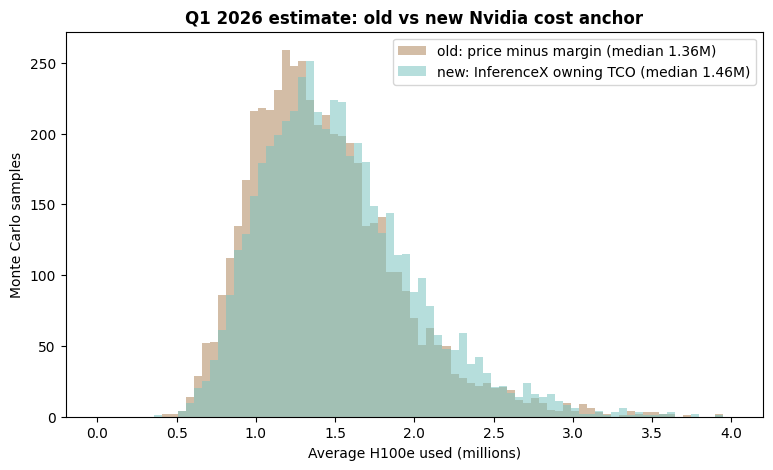

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 4, 80)
ax.hist(old_h100e_q1_2026 / 1e6, bins=bins, alpha=0.55, color="#B0885E",
        label=f"old: price minus margin (median {fmt(p_old_q1[50])})")
ax.hist(h100e_q1_2026 / 1e6, bins=bins, alpha=0.55, color="#7AC4C0",
        label=f"new: InferenceX owning TCO (median {fmt(p_q1[50])})")
ax.set_xlabel("Average H100e used (millions)")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("Q1 2026 estimate: old vs new Nvidia cost anchor", weight="bold")
ax.legend()
plt.show()

## Sanity checks & caveats

- **Consistency with the DeepMind top-down model.** The separate DeepMind model
  (allocating Google's *installed* fleet) puts DeepMind at roughly **1.5–2M
  H100e** including inference. This spending model — R&D/training only, and an
  *upper bound* since it assumes all compute-dollars are DeepMind's — lands in a
  similar range at its median. That's reassuring, but also a tension: an
  R&D-only *upper bound* shouldn't sit *above* the all-in top-down estimate. If
  it does, that argues the true internal cost is toward the higher end of our
  range (or the compute share toward the lower end).
- **Upper-bound framing.** This attributes the entire compute portion of the
  bucket to DeepMind R&D. In reality some may be non-frontier, and conversely
  some DeepMind R&D (e.g. product-specific post-training for Search) may be
  booked in a business segment and *missed* here. These roughly offset but the
  net sign is unknown.
- **No inference.** Product/API inference is in the business segments, so this
  is strictly a training/research figure — not comparable to a lab's *total*
  fleet.
- **Cost basis, not price.** The output is not comparable to OpenAI's/Anthropic's
  cloud spend converted at market GPU-hour rates. Market H100 rentals run
  ~$1.50–2.00/hr against a ~$1.30 owning TCO, so multiply the internal cost by
  roughly 1.2–1.5× to get a market-equivalent, which would *lower* the H100e
  count.

In [12]:
print("Summary — average H100e used for Alphabet-level activities\n")
for label, p in [("Q1 2026", p_q1), ("FY 2025 (annual avg)", p_fy)]:
    print(f"{label}")
    print(f"  90% CI : {fmt(p[5])} – {fmt(p[95])}")
    print(f"  median : {fmt(p[50])}")
    print()

Summary — average H100e used for Alphabet-level activities

Q1 2026
  90% CI : 863k – 2.41M
  median : 1.46M

FY 2025 (annual avg)
  90% CI : 661k – 1.85M
  median : 1.12M

